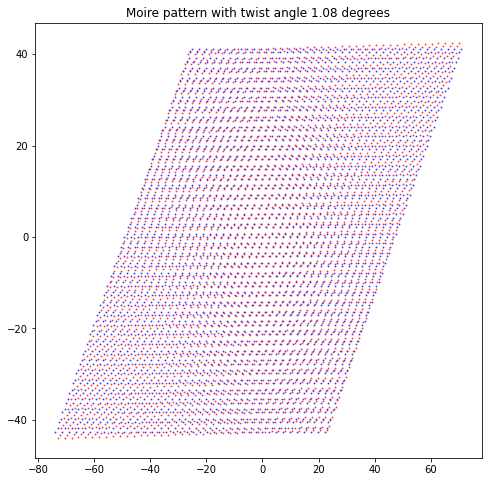

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

def generate_graphene_lattice(a, size):
    x = []
    y = []
    for i in range(-size, size):
        for j in range(-size, size):
            x.append(a * (i + j/2))
            y.append(a * np.sqrt(3) * j / 2)
            x.append(a * (i + j/2 + 1/3))
            y.append(a * np.sqrt(3) * (j + 1/3) / 2)
    return np.array(x), np.array(y)

def rotate_lattice(x, y, angle):
    angle_rad = np.deg2rad(angle)
    x_rot = x * np.cos(angle_rad) - y * np.sin(angle_rad)
    y_rot = x * np.sin(angle_rad) + y * np.cos(angle_rad)
    return x_rot, y_rot

# 파라미터 설정
a = 2.46  # 그래핀의 격자 상수
size = 20  # 격자 크기

# 두 개의 격자 생성
x1, y1 = generate_graphene_lattice(a, size)
x2, y2 = generate_graphene_lattice(a, size)

# 두 번째 격자를 회전
twist_angle = 1.08  # 각도 설정 (예: 5도)
x2_rot, y2_rot = rotate_lattice(x2, y2, twist_angle)

# 모아레 패턴 생성
plt.figure(figsize=(8, 8))
plt.scatter(x1, y1, s=1, color='b', alpha=0.6)
plt.scatter(x2_rot, y2_rot, s=1, color='r', alpha=0.6)
plt.title(f'Moire pattern with twist angle {twist_angle} degrees')
plt.show()


In [11]:
import os
from twister import Twister

# 이미지 저장 경로 설정
output_dir = 'stacking_images'
os.makedirs(output_dir, exist_ok=True)

# 스태킹 패턴 리스트 (AA, AB, BA)
patterns = ['AA', 'AB', 'BA']

# 각 스태킹 패턴에 대한 이미지 생성
for pattern in patterns:
    for i in range(100):  # 각 패턴 당 100개의 이미지를 생성한다고 가정
        moire = Twister('graphene', 'graphene', twist_angle=1.1)
        image = moire.generate_moire(stacking_pattern=pattern)
        image.save(f"{output_dir}/{pattern}_{i}.png")

ImportError: cannot import name 'Twister' from 'twister' (/home/student/2021/2021550036/DFT/twister.py)

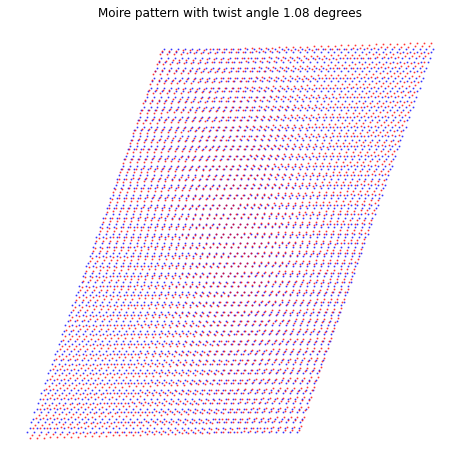

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def generate_graphene_lattice(a, size):
    x = []
    y = []
    for i in range(-size, size):
        for j in range(-size, size):
            x.append(a * (i + j/2))
            y.append(a * np.sqrt(3) * j / 2)
            x.append(a * (i + j/2 + 1/3))
            y.append(a * np.sqrt(3) * (j + 1/3) / 2)
    return np.array(x), np.array(y)

def rotate_lattice(x, y, angle):
    angle_rad = np.deg2rad(angle)
    x_rot = x * np.cos(angle_rad) - y * np.sin(angle_rad)
    y_rot = x * np.sin(angle_rad) + y * np.cos(angle_rad)
    return x_rot, y_rot

# 파라미터 설정
a = 2.46  # 그래핀의 격자 상수
size = 20  # 격자 크기

# 두 개의 격자 생성
x1, y1 = generate_graphene_lattice(a, size)
x2, y2 = generate_graphene_lattice(a, size)

# 두 번째 격자를 회전
twist_angle = 1.08  # 각도 설정 (예: 5도)
x2_rot, y2_rot = rotate_lattice(x2, y2, twist_angle)

# 모아레 패턴 생성 및 이미지 저장
plt.figure(figsize=(8, 8))
plt.scatter(x1, y1, s=1, color='b', alpha=0.6)
plt.scatter(x2_rot, y2_rot, s=1, color='r', alpha=0.6)
plt.title(f'Moire pattern with twist angle {twist_angle} degrees')
plt.axis('off')  # 축을 제거하여 패턴만 표시
plt.savefig('moire_pattern.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [1]:
import cv2
import numpy as np

# 이미지 읽기
image = cv2.imread('moire_pattern.png')

# 특정 스태킹 영역(AA, AB, BA 등) 좌표 설정
# 예를 들어, (x, y, w, h)는 영역의 왼쪽 위 모서리 좌표 (x, y)와 너비(w), 높이(h)를 나타냅니다.
# 각 스태킹 영역의 좌표는 수동으로 설정하거나 특정 알고리즘을 통해 자동으로 추출할 수 있습니다.
x, y, w, h = 100, 100, 200, 200  # 예시 좌표

# 스태킹 영역 자르기
cropped_image = image[y:y+h, x:x+w]

# 자른 이미지 저장
cv2.imwrite('stacking_region_AA.png', cropped_image)

# 다른 영역들도 동일한 방식으로 자르기
# x, y, w, h 값을 다르게 설정하여 AB, BA 영역도 자를 수 있습니다.

True

In [2]:
# 예를 들어, AB 영역 추출 및 저장
x_ab, y_ab, w_ab, h_ab = 300, 300, 200, 200  # AB 영역의 좌표
cropped_image_ab = image[y_ab:y_ab+h_ab, x_ab:x_ab+w_ab]
cv2.imwrite('stacking_region_AB.png', cropped_image_ab)

# BA 영역도 동일한 방식으로 추출하여 저장합니다.

True

In [3]:
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 이미지 전처리 함수
def preprocess_image(image_path, target_size=(64, 64)):
    image = Image.open(image_path)
    image = image.resize(target_size)
    image = np.array(image)
    image = image / 255.0  # 정규화
    return image

# 데이터셋 로드 및 전처리
def load_dataset(image_paths, labels):
    X = []
    y = []
    for img_path, label in zip(image_paths, labels):
        img = preprocess_image(img_path)
        X.append(img)
        y.append(label)
    X = np.array(X)
    y = np.array(y)
    return X, y

# 데이터셋 분할
image_paths = ['path_to_image1', 'path_to_image2', ...]  # 이미지 경로 리스트
labels = ['AA', 'AB', 'BA', ...]  # 해당 이미지의 레이블 리스트
X, y = load_dataset(image_paths, labels)

# 레이블 인코딩 및 one-hot 인코딩
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# 학습 데이터와 테스트 데이터로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)


TypeError: Descriptors cannot be created directly.
If this call came from a _pb2.py file, your generated code is out of date and must be regenerated with protoc >= 3.19.0.
If you cannot immediately regenerate your protos, some other possible workarounds are:
 1. Downgrade the protobuf package to 3.20.x or lower.
 2. Set PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION=python (but this will use pure-Python parsing and will be much slower).

More information: https://developers.google.com/protocol-buffers/docs/news/2022-05-06#python-updates